In [1]:
# Import libraries
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv("heart_disease_dataset.csv")

# Display first 5 rows
df.head()

,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Smoking,Alcohol Intake,Exercise Hours,Family History,Diabetes,Obesity,Stress Level,Blood Sugar,Exercise Induced Angina,Chest Pain Type,Heart Disease
0,75,Female,228,119,66,Current,Heavy,1,No,No,Yes,8,119,Yes,Atypical Angina,1
1,48,Male,204,165,62,Current,NaN,5,No,No,No,9,70,Yes,Typical Angina,0
2,53,Male,234,91,67,Never,Heavy,3,Yes,No,Yes,5,196,Yes,Atypical Angina,1
3,69,Female,192,90,72,Current,NaN,4,No,Yes,No,7,107,Yes,Non-anginal Pain,0
4,62,Female,172,163,93,Never,NaN,6,No,Yes,No,2,183,Yes,Asymptomatic,0


In [2]:
df.describe()

,Age,Cholesterol,Blood Pressure,Heart Rate,Exercise Hours,Stress Level,Blood Sugar,Heart Disease
count,1000.000000,1000.000000,1000.0000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,52.293000,249.939000,135.2810,79.204000,4.529000,5.646000,134.941000,0.392000
std,15.727126,57.914673,26.3883,11.486092,2.934241,2.831024,36.699624,0.488441
min,25.000000,150.000000,90.0000,60.000000,0.000000,1.000000,70.000000,0.000000
25%,39.000000,200.000000,112.7500,70.000000,2.000000,3.000000,104.000000,0.000000
50%,52.000000,248.000000,136.0000,79.000000,4.500000,6.000000,135.000000,0.000000
75%,66.000000,299.000000,159.0000,89.000000,7.000000,8.000000,167.000000,1.000000
max,79.000000,349.000000,179.0000,99.000000,9.000000,10.000000,199.000000,1.000000


In [3]:
df.shape

(1000, 16)

In [4]:
df.columns

Index(['Age', 'Gender', 'Cholesterol', 'Blood Pressure', 'Heart Rate',
       'Smoking', 'Alcohol Intake', 'Exercise Hours', 'Family History',
       'Diabetes', 'Obesity', 'Stress Level', 'Blood Sugar',
       'Exercise Induced Angina', 'Chest Pain Type', 'Heart Disease'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      1000 non-null   int64 
 1   Gender                   1000 non-null   object
 2   Cholesterol              1000 non-null   int64 
 3   Blood Pressure           1000 non-null   int64 
 4   Heart Rate               1000 non-null   int64 
 5   Smoking                  1000 non-null   object
 6   Alcohol Intake           660 non-null    object
 7   Exercise Hours           1000 non-null   int64 
 8   Family History           1000 non-null   object
 9   Diabetes                 1000 non-null   object
 10  Obesity                  1000 non-null   object
 11  Stress Level             1000 non-null   int64 
 12  Blood Sugar              1000 non-null   int64 
 13  Exercise Induced Angina  1000 non-null   object
 14  Chest Pain Type          1000 non-null   

In [7]:
import os
import shutil

# Create folders
os.makedirs("raw", exist_ok=True)
os.makedirs("gold", exist_ok=True)

# Copy original dataset into raw folder
shutil.copy("heart_disease_dataset.csv", "raw/heart_disease_dataset.csv")

print("Folders created successfully!")

Folders created successfully!


In [8]:
df.isnull().sum()

,0
Age,0
Gender,0
Cholesterol,0
Blood Pressure,0
Heart Rate,0
Smoking,0
Alcohol Intake,340
Exercise Hours,0
Family History,0
Diabetes,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
# Fill missing values in categorical columns with the mode

categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Check missing values again
df.isnull().sum()

/tmp/ipykernel_4861/2764924662.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


,0
Age,0
Gender,0
Cholesterol,0
Blood Pressure,0
Heart Rate,0
Smoking,0
Alcohol Intake,0
Exercise Hours,0
Family History,0
Diabetes,0


In [11]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Missing Values:
Age                        0
Gender                     0
Cholesterol                0
Blood Pressure             0
Heart Rate                 0
Smoking                    0
Alcohol Intake             0
Exercise Hours             0
Family History             0
Diabetes                   0
Obesity                    0
Stress Level               0
Blood Sugar                0
Exercise Induced Angina    0
Chest Pain Type            0
Heart Disease              0
dtype: int64

Duplicate Rows:
0

Data Types:
Age                         int64
Gender                     object
Cholesterol                 int64
Blood Pressure              int64
Heart Rate                  int64
Smoking                    object
Alcohol Intake             object
Exercise Hours              int64
Family History             object
Diabetes                   object
Obesity                    object
Stress Level                int64
Blood Sugar                 int64
Exercise Induced Angina    object

In [12]:
# Save cleaned dataset

df.to_csv("gold/clean_data.csv", index=False)

print("Clean dataset saved successfully!")

print("Final Shape:", df.shape)

Clean dataset saved successfully!
Final Shape: (1000, 16)


In [13]:
import sqlite3

conn = sqlite3.connect("heart_disease.db")

print("Database created successfully!")

Database created successfully!


In [14]:
cursor = conn.cursor()

cursor.execute("SELECT sqlite_version();")
print(cursor.fetchone())

('3.37.2',)


In [15]:
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE Patient (
    PatientID INTEGER PRIMARY KEY AUTOINCREMENT,
    Age INTEGER,
    Gender TEXT,
    FamilyHistory TEXT,
    Diabetes TEXT,
    Obesity TEXT
)
""")

cursor.execute("""
CREATE TABLE HealthMetrics (
    MetricID INTEGER PRIMARY KEY AUTOINCREMENT,
    PatientID INTEGER,
    Cholesterol INTEGER,
    BloodPressure INTEGER,
    HeartRate INTEGER,
    BloodSugar INTEGER,
    StressLevel INTEGER,
    FOREIGN KEY (PatientID) REFERENCES Patient(PatientID)
)
""")

cursor.execute("""
CREATE TABLE Lifestyle (
    LifestyleID INTEGER PRIMARY KEY AUTOINCREMENT,
    PatientID INTEGER,
    Smoking TEXT,
    AlcoholIntake TEXT,
    ExerciseHours INTEGER,
    ExerciseInducedAngina TEXT,
    ChestPainType TEXT,
    FOREIGN KEY (PatientID) REFERENCES Patient(PatientID)
)
""")

cursor.execute("""
CREATE TABLE HeartDisease (
    RecordID INTEGER PRIMARY KEY AUTOINCREMENT,
    PatientID INTEGER,
    HeartDisease INTEGER,
    FOREIGN KEY (PatientID) REFERENCES Patient(PatientID)
)
""")

conn.commit()

print("Tables created successfully!")

Tables created successfully!


In [16]:
df.describe()

,Age,Cholesterol,Blood Pressure,Heart Rate,Exercise Hours,Stress Level,Blood Sugar,Heart Disease
count,1000.000000,1000.000000,1000.0000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,52.293000,249.939000,135.2810,79.204000,4.529000,5.646000,134.941000,0.392000
std,15.727126,57.914673,26.3883,11.486092,2.934241,2.831024,36.699624,0.488441
min,25.000000,150.000000,90.0000,60.000000,0.000000,1.000000,70.000000,0.000000
25%,39.000000,200.000000,112.7500,70.000000,2.000000,3.000000,104.000000,0.000000
50%,52.000000,248.000000,136.0000,79.000000,4.500000,6.000000,135.000000,0.000000
75%,66.000000,299.000000,159.0000,89.000000,7.000000,8.000000,167.000000,1.000000
max,79.000000,349.000000,179.0000,99.000000,9.000000,10.000000,199.000000,1.000000


In [17]:
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    print("="*50)
    print(col)
    print(df[col].value_counts())

Gender
Gender
Female    503
Male      497
Name: count, dtype: int64
Smoking
Smoking
Never      338
Current    336
Former     326
Name: count, dtype: int64
Alcohol Intake
Alcohol Intake
Heavy       686
Moderate    314
Name: count, dtype: int64
Family History
Family History
No     501
Yes    499
Name: count, dtype: int64
Diabetes
Diabetes
Yes    505
No     495
Name: count, dtype: int64
Obesity
Obesity
No     501
Yes    499
Name: count, dtype: int64
Exercise Induced Angina
Exercise Induced Angina
No     528
Yes    472
Name: count, dtype: int64
Chest Pain Type
Chest Pain Type
Non-anginal Pain    256
Typical Angina      250
Asymptomatic        248
Atypical Angina     246
Name: count, dtype: int64


In [18]:
missing = df.isnull().sum()

missing_percent = (missing/len(df))*100

summary = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percent
})

summary

,Missing Values,Percentage
Age,0,0.0
Gender,0,0.0
Cholesterol,0,0.0
Blood Pressure,0,0.0
Heart Rate,0,0.0
Smoking,0,0.0
Alcohol Intake,0,0.0
Exercise Hours,0,0.0
Family History,0,0.0
Diabetes,0,0.0


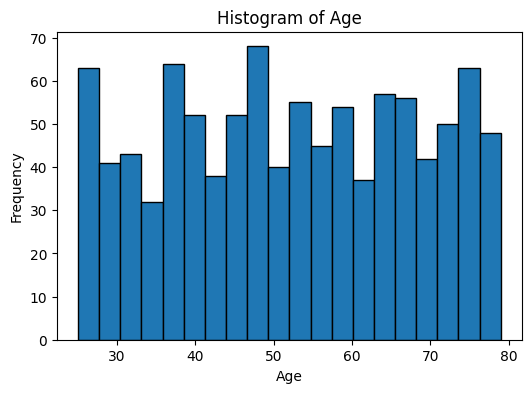

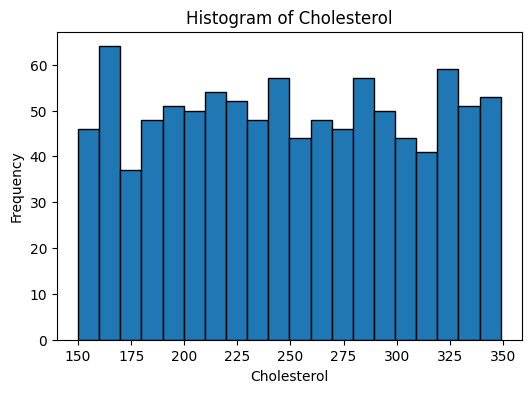

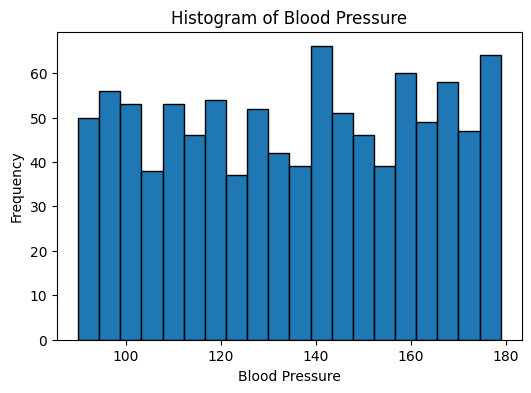

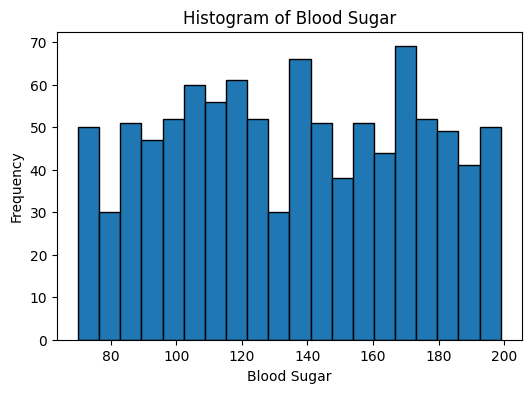

In [19]:
import matplotlib.pyplot as plt

# Select numerical columns
numerical_columns = [
    "Age",
    "Cholesterol",
    "Blood Pressure",
    "Blood Sugar"
]

for col in numerical_columns:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=20, edgecolor='black')
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

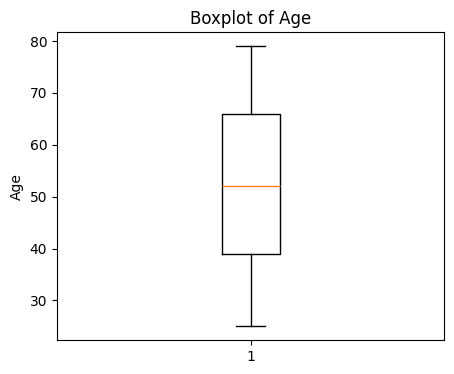

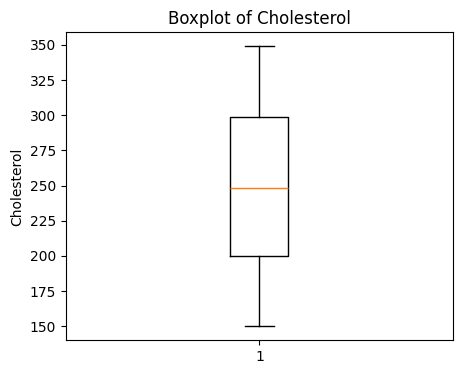

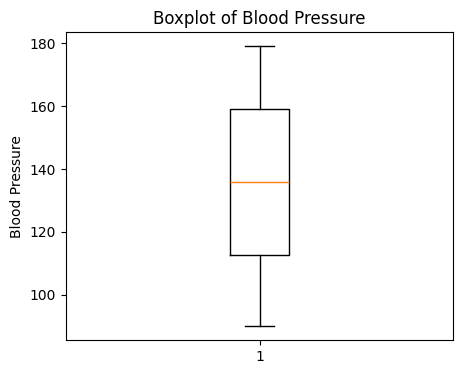

In [20]:
box_columns = [
    "Age",
    "Cholesterol",
    "Blood Pressure"
]

for col in box_columns:
    plt.figure(figsize=(5,4))
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

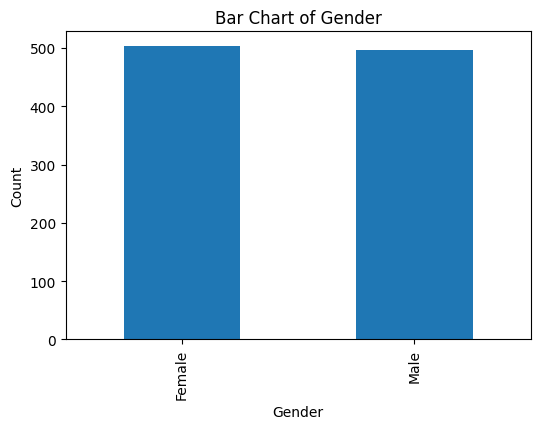

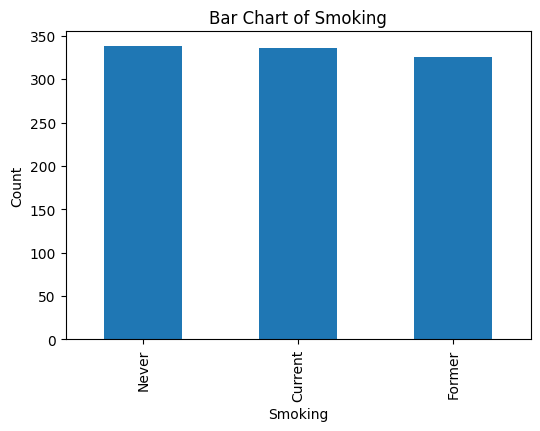

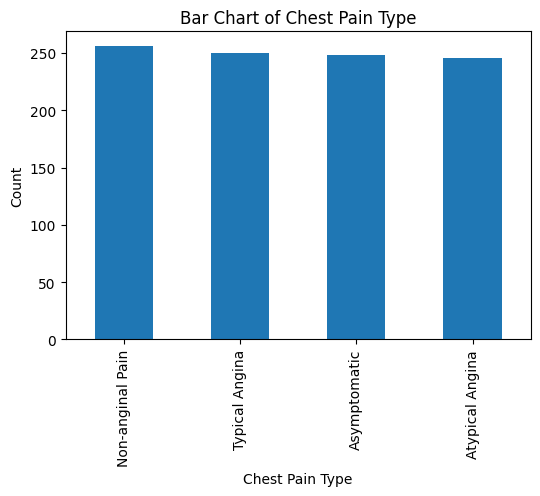

In [21]:
categorical_columns = [
    "Gender",
    "Smoking",
    "Chest Pain Type"
]

for col in categorical_columns:
    plt.figure(figsize=(6,4))
    df[col].value_counts().plot(kind='bar')
    plt.title(f"Bar Chart of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

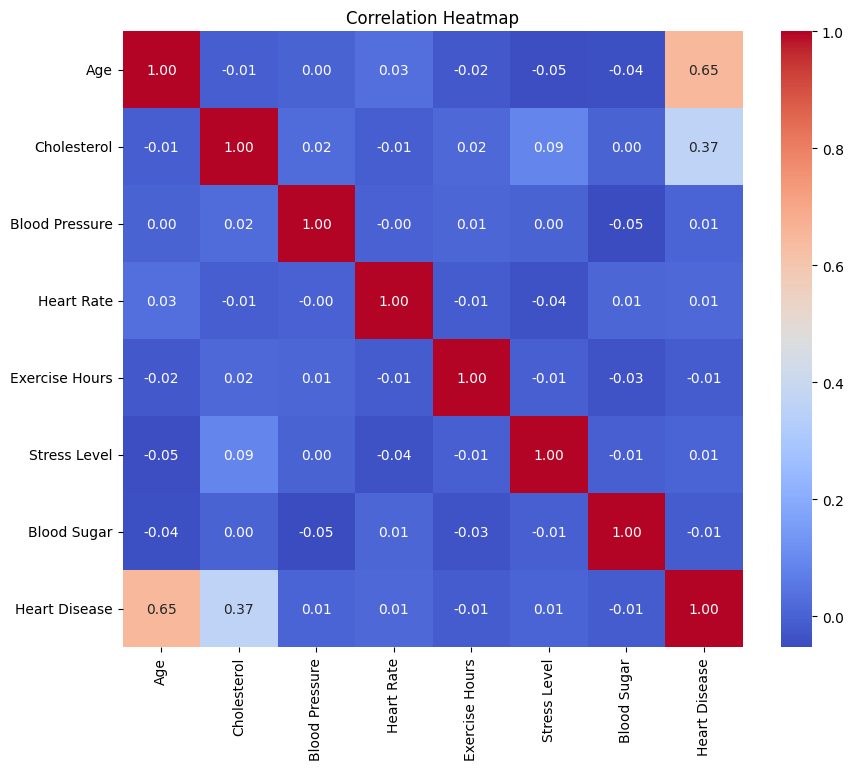

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

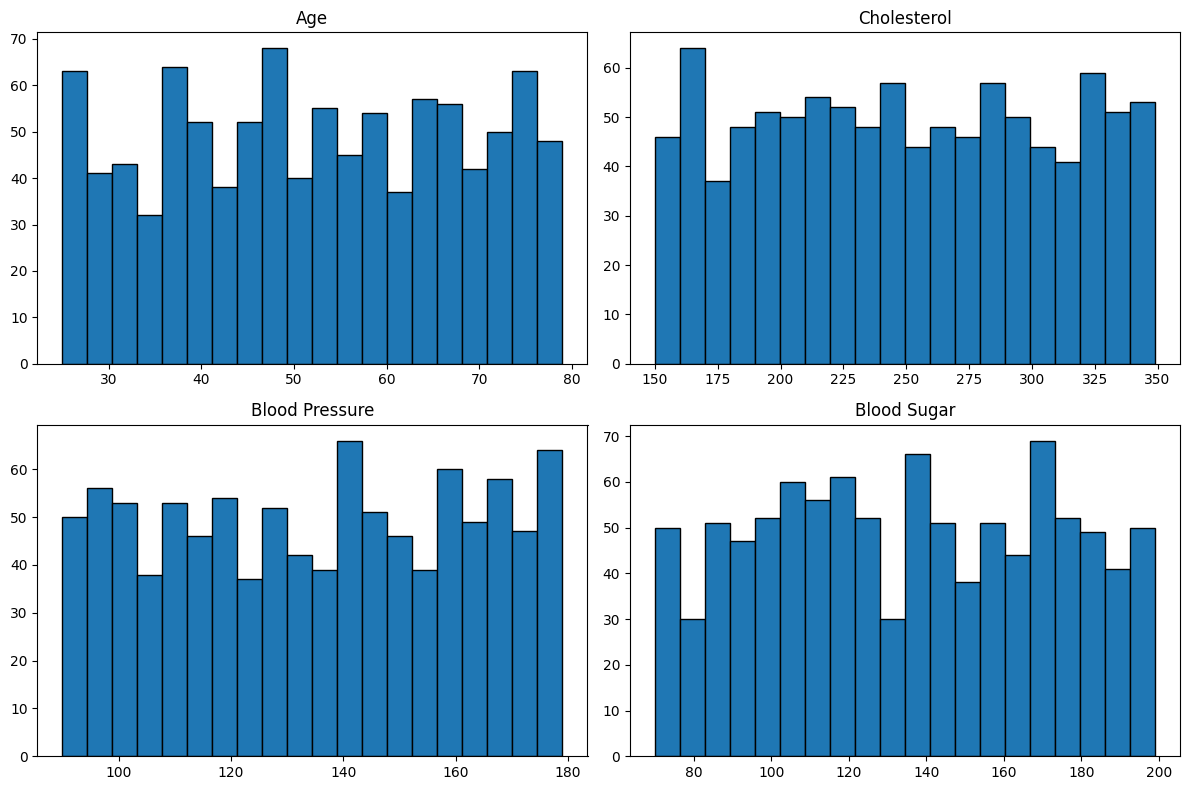

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

columns = ["Age", "Cholesterol", "Blood Pressure", "Blood Sugar"]

for ax, col in zip(axes.flatten(), columns):
    ax.hist(df[col], bins=20, edgecolor="black")
    ax.set_title(col)

plt.tight_layout()
plt.show()

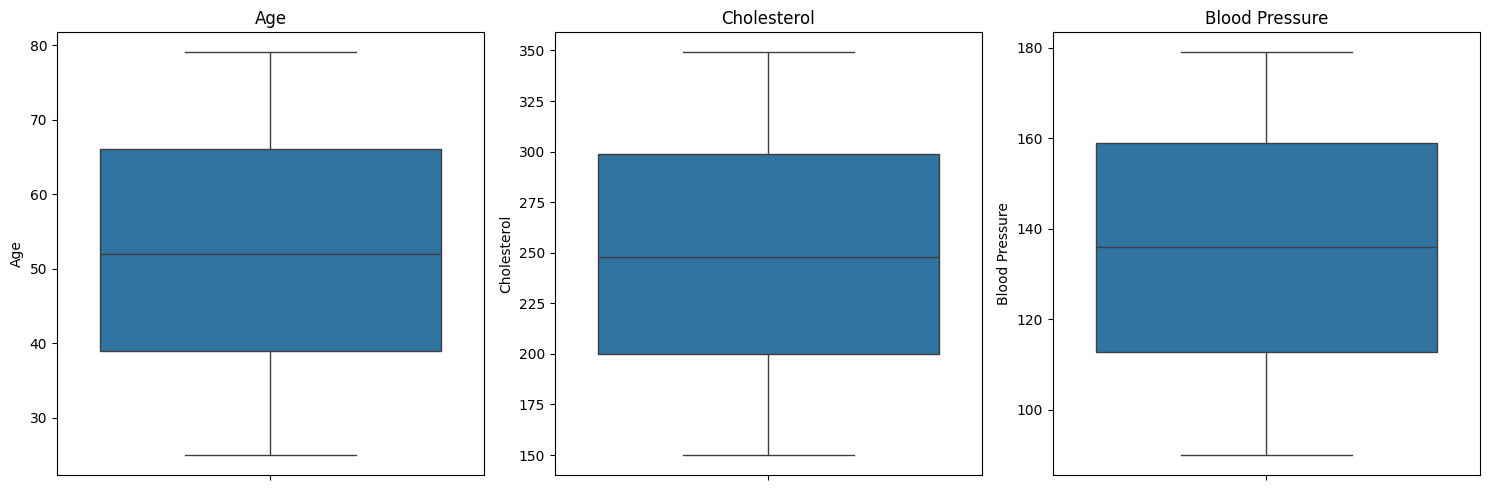

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(y=df["Age"], ax=axes[0])
axes[0].set_title("Age")

sns.boxplot(y=df["Cholesterol"], ax=axes[1])
axes[1].set_title("Cholesterol")

sns.boxplot(y=df["Blood Pressure"], ax=axes[2])
axes[2].set_title("Blood Pressure")

plt.tight_layout()
plt.show()

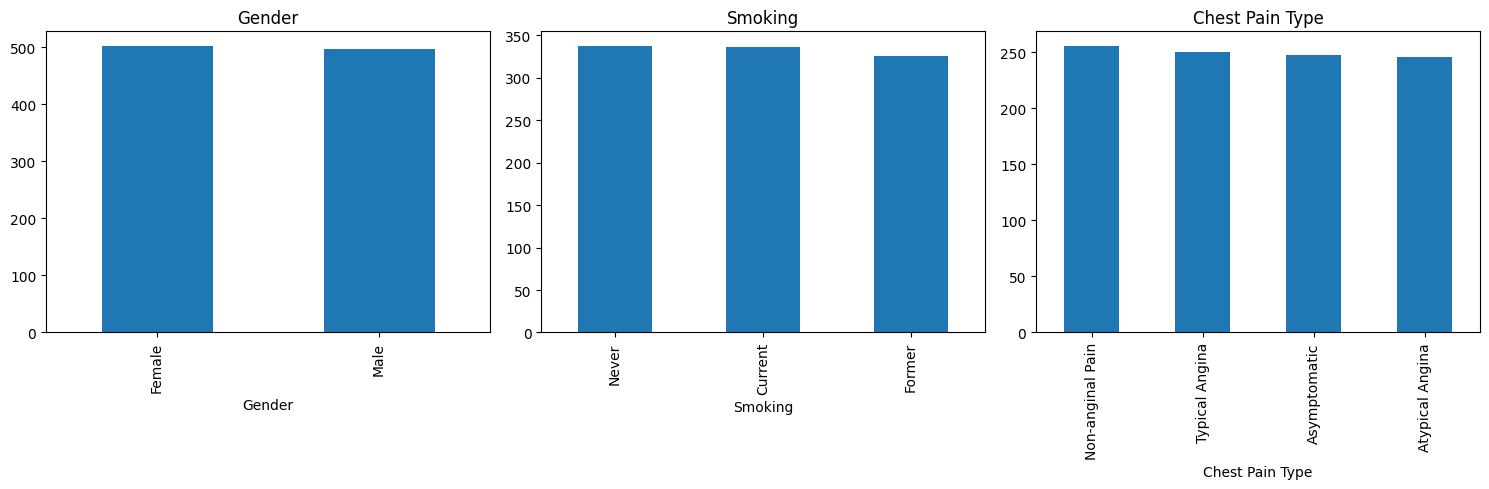

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

df["Gender"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Gender")

df["Smoking"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Smoking")

df["Chest Pain Type"].value_counts().plot(kind="bar", ax=axes[2])
axes[2].set_title("Chest Pain Type")

plt.tight_layout()
plt.show()

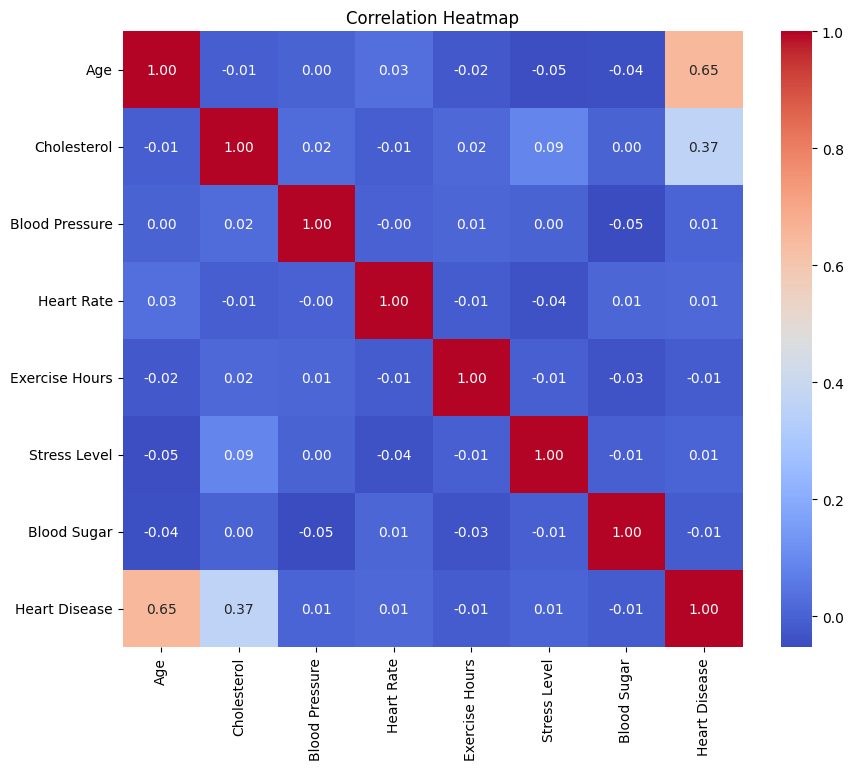

In [26]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

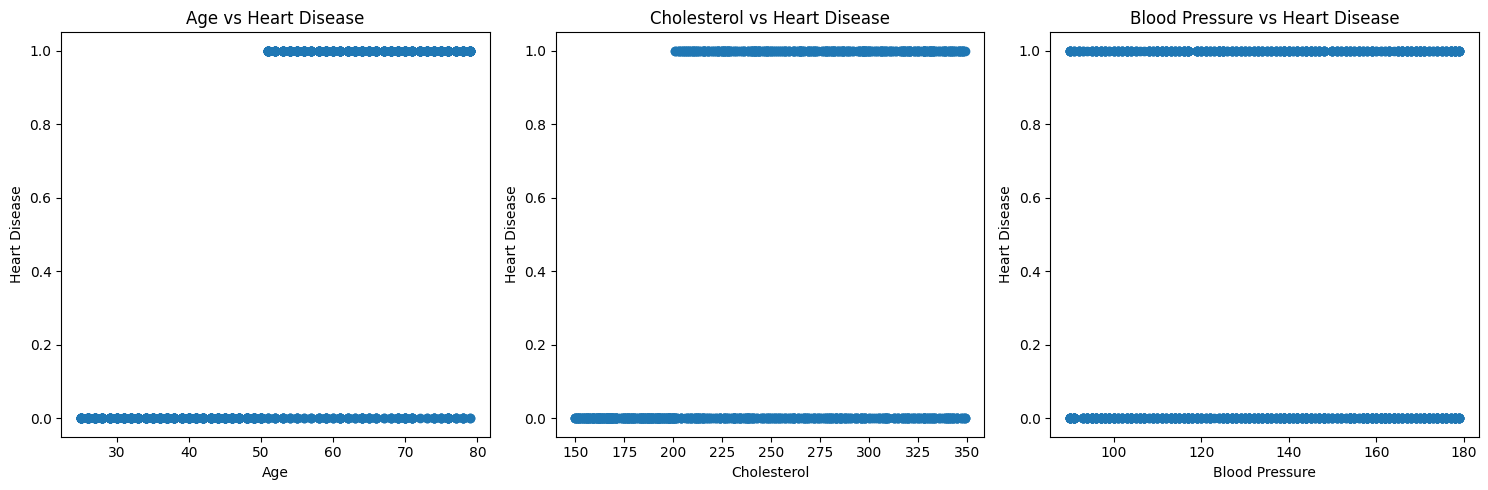

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(df["Age"], df["Heart Disease"])
axes[0].set_title("Age vs Heart Disease")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Heart Disease")

axes[1].scatter(df["Cholesterol"], df["Heart Disease"])
axes[1].set_title("Cholesterol vs Heart Disease")
axes[1].set_xlabel("Cholesterol")
axes[1].set_ylabel("Heart Disease")

axes[2].scatter(df["Blood Pressure"], df["Heart Disease"])
axes[2].set_title("Blood Pressure vs Heart Disease")
axes[2].set_xlabel("Blood Pressure")
axes[2].set_ylabel("Heart Disease")

plt.tight_layout()
plt.show()

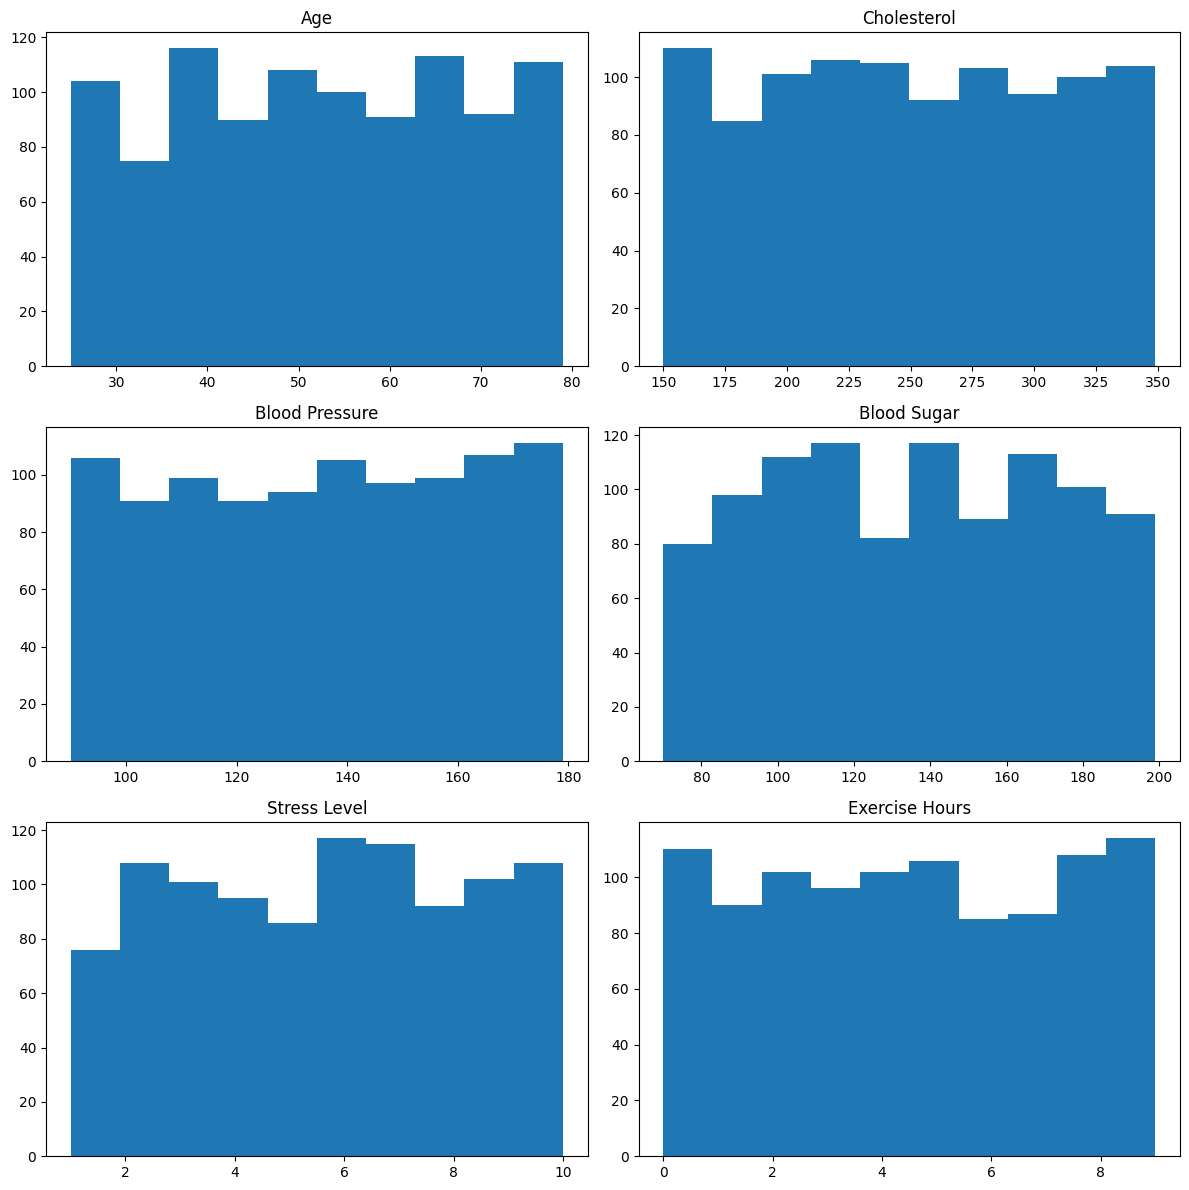

In [28]:
fig, ax = plt.subplots(3, 2, figsize=(12, 12))

ax[0,0].hist(df["Age"])
ax[0,0].set_title("Age")

ax[0,1].hist(df["Cholesterol"])
ax[0,1].set_title("Cholesterol")

ax[1,0].hist(df["Blood Pressure"])
ax[1,0].set_title("Blood Pressure")

ax[1,1].hist(df["Blood Sugar"])
ax[1,1].set_title("Blood Sugar")

ax[2,0].hist(df["Stress Level"])
ax[2,0].set_title("Stress Level")

ax[2,1].hist(df["Exercise Hours"])
ax[2,1].set_title("Exercise Hours")

plt.tight_layout()
plt.show()

In [29]:
df.groupby("Heart Disease")["Cholesterol"].mean()

,Cholesterol
Heart Disease,
0,232.972039
1,276.255102


In [30]:
df.groupby("Heart Disease")["Age"].mean()

,Age
Heart Disease,
0,44.128289
1,64.956633


In [31]:
df.groupby("Heart Disease")["Exercise Hours"].mean()

,Exercise Hours
Heart Disease,
0,4.562500
1,4.477041


In [32]:
df.groupby("Heart Disease")["Blood Pressure"].mean()

,Blood Pressure
Heart Disease,
0,135.134868
1,135.507653


In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Create a copy
model_df = df.copy()

# Encode categorical columns
label_encoder = LabelEncoder()

categorical_cols = model_df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    model_df[col] = label_encoder.fit_transform(model_df[col])

# Features and Target
X = model_df.drop("Heart Disease", axis=1)
y = model_df["Heart Disease"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (800, 15)
Testing Shape: (200, 15)


In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.865


In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 1.0


In [36]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

gb_accuracy = accuracy_score(y_test, gb_pred)

print("Gradient Boosting Accuracy:", gb_accuracy)

Gradient Boosting Accuracy: 1.0


In [37]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        gb_accuracy
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.865
1,Random Forest,1.000
2,Gradient Boosting,1.000


In [38]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importance from Random Forest
importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

# Sort values
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,Age,0.530594
2,Cholesterol,0.259490
3,Blood Pressure,0.038175
12,Blood Sugar,0.034710
4,Heart Rate,0.031817
7,Exercise Hours,0.022911
11,Stress Level,0.021620
5,Smoking,0.013328
14,Chest Pain Type,0.011531
13,Exercise Induced Angina,0.006446


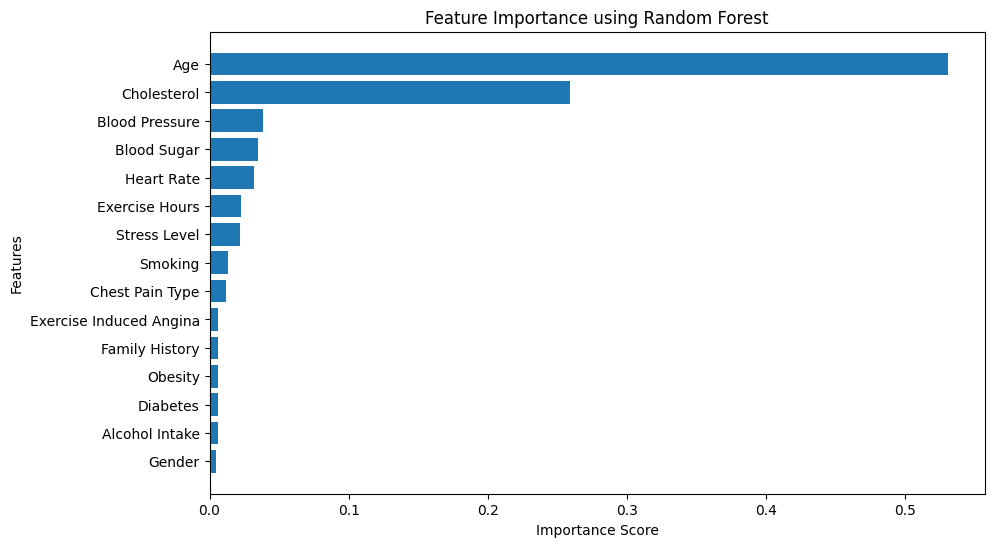

In [39]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance using Random Forest")

plt.gca().invert_yaxis()

plt.show()

In [40]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

estimators = [
    ("rf", RandomForestClassifier(random_state=42)),
    ("gb", GradientBoostingClassifier(random_state=42))
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000)
)

stack_model.fit(X_train, y_train)

stack_pred = stack_model.predict(X_test)

from sklearn.metrics import accuracy_score

stack_accuracy = accuracy_score(y_test, stack_pred)

print("Stacking Accuracy:", stack_accuracy)

Stacking Accuracy: 1.0


In [41]:
!pip install shap

In [42]:
import shap

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test)

print("SHAP values generated successfully!")

SHAP values generated successfully!


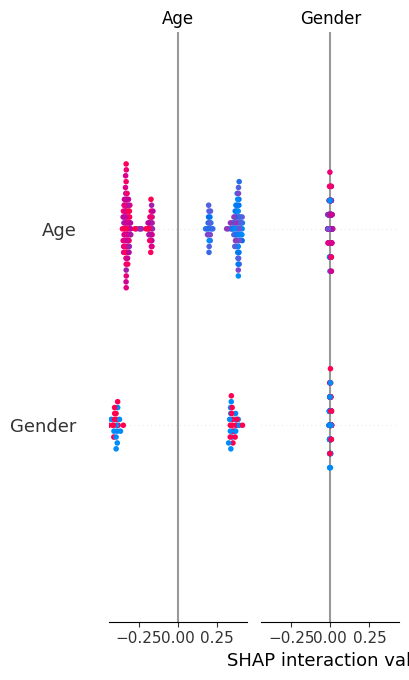

In [43]:
shap.summary_plot(shap_values, X_test)

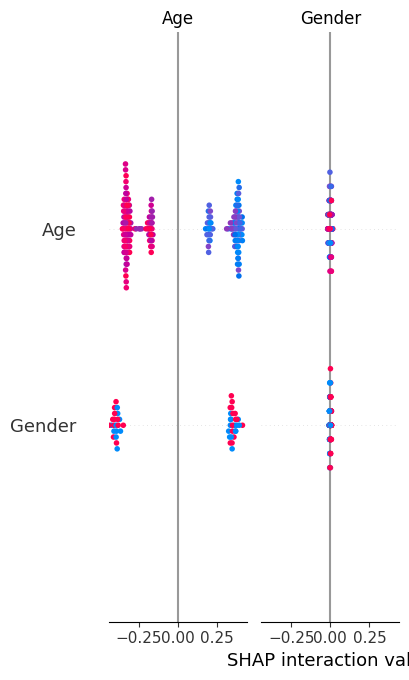

In [44]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [45]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf, X, y, cv=5)

print("Cross Validation Scores:")
print(cv_scores)

print("Average Accuracy:", cv_scores.mean())

Cross Validation Scores:
[1.    0.995 1.    0.995 1.   ]
Average Accuracy: 0.998


In [46]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'max_depth': None, 'n_estimators': 200}
Best Score: 0.9950062421972534


In [47]:
sample_patient = [[
    55,        # Age
    1,         # Gender (Male=1, Female=0)
    240,       # Cholesterol
    145,       # Blood Pressure
    80,        # Heart Rate
    1,         # Smoking
    1,         # Alcohol Intake
    4,         # Exercise Hours
    1,         # Family History
    0,         # Diabetes
    0,         # Obesity
    5,         # Stress Level
    130,       # Blood Sugar
    0,         # Exercise Induced Angina
    2          # Chest Pain Type
]]

prediction = rf.predict(sample_patient)

if prediction[0] == 1:
    print("Predicted Result: Heart Disease Detected")
else:
    print("Predicted Result: No Heart Disease")

Predicted Result: Heart Disease Detected


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
